# CSC 659/859 HW2: Random Forest Gene Expression Classification

This notebook follows the same order as the written report:

1. Setup and imports  
2. Section 2: Audit of the original database  
3. Section 3: Create the training and verification databases  
4. Section 6: Method 1, out-of-bag Random Forest evaluation  
5. Section 6: Method 2, 3-fold stratified cross-validation  
6. Section 6: Compare OOB and CV accuracy  
7. Section 7: Feature ranking and feature-importance plot  
8. Section 8: Final runtime test on the verification database

The final model used in the report is:

- `n_estimators = 500`
- `max_features = 50`
- `random_state = 42`


## 1. Setup and Imports

Run this cell first. It loads the libraries, sets the file paths, and defines helper functions used later in the notebook.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# If this notebook is in notebooks/, these paths point to the repo folders.
DATA_DIR = Path("../data")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ORIGINAL_DATA_PATH = DATA_DIR / "i1_cluster.csv"
TRAINING_DATA_PATH = DATA_DIR / "training_db.csv"
VERIFICATION_DATA_PATH = DATA_DIR / "verification_db.csv"

BEST_NTREE = 500
BEST_MTRY = 50


def metrics_from_cm(cm):
    """Return accuracy, precision, recall, specificity, and F1 from a 2x2 confusion matrix.

    Matrix format with labels=[0, 1]:
        [[TN, FP],
         [FN, TP]]
    """
    TN, FP = cm[0, 0], cm[0, 1]
    FN, TP = cm[1, 0], cm[1, 1]
    total = TN + FP + FN + TP

    accuracy = (TP + TN) / total if total else 0.0
    precision = TP / (TP + FP) if (TP + FP) else 0.0
    recall = TP / (TP + FN) if (TP + FN) else 0.0
    specificity = TN / (TN + FP) if (TN + FP) else 0.0
    f1 = (2 * TP) / (2 * TP + FP + FN) if (2 * TP + FP + FN) else 0.0

    return accuracy, precision, recall, specificity, f1


def dataset_summary(dataframe, label_col="Label"):
    """Create a summary table for a dataframe with a binary Label column."""
    num_samples = dataframe.shape[0]
    num_features = dataframe.shape[1] - 1
    class_counts = dataframe[label_col].value_counts().sort_index()
    class_percent = dataframe[label_col].value_counts(normalize=True).sort_index() * 100
    missing_values = dataframe.isnull().sum().sum()
    sample_feature_ratio = num_samples / num_features if num_features else np.nan

    return pd.DataFrame({
        "Metric": [
            "Number of Samples",
            "Number of Features",
            "Class 0 Samples",
            "Class 1 Samples",
            "% Class 0",
            "% Class 1",
            "Missing Values",
            "Sample-to-Feature Ratio",
        ],
        "Value": [
            num_samples,
            num_features,
            int(class_counts.get(0, 0)),
            int(class_counts.get(1, 0)),
            round(class_percent.get(0, 0.0), 5),
            round(class_percent.get(1, 0.0), 5),
            int(missing_values),
            round(sample_feature_ratio, 5),
        ],
    })


## 2. Section 2: Audit of Original Database

This section loads the original database and reports the basic dataset statistics used in the report.


In [2]:
df = pd.read_csv(ORIGINAL_DATA_PATH)

print("Original dataset shape:", df.shape)
df.head()


Original dataset shape: (871, 609)


,GABRG2,CELF4,SRRM4,SLC1A3,ATP1A3,RBFOX3,GABRA4,NHSL1,GRAMD3,SEZ6L2,...,FERMT1,CSPG4,GJA1,LAMA1,YAP1,LINC00639.2,SMOC1,LINC00498,GFRA1,Label
0,35.038262,161.176004,68.074337,58.063405,20.021864,269.294069,188.205520,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,1.001093,0.0,0.0,0
1,95.324867,75.256474,87.297510,0.000000,18.061554,342.166102,683.328784,0.000000,0.0,1.003420,...,0.0,0.0,0.0,0.0,0.0,0.000000,1.003420,0.0,0.0,0
2,220.143867,187.976727,42.219372,106.553653,0.000000,187.976727,299.556496,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,7.036562,0.000000,0.0,0.0,0
3,166.010840,26.159284,61.373704,0.000000,30.183789,254.549955,446.720079,0.000000,0.0,25.153158,...,0.0,0.0,0.0,0.0,0.0,0.000000,1.006126,0.0,0.0,0
4,188.426220,71.160966,119.269788,57.129226,16.036274,265.600789,287.650666,24.054411,0.0,1.002267,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0


In [3]:
original_summary = dataset_summary(df)
original_summary


,Metric,Value
0,Number of Samples,871.00000
1,Number of Features,608.00000
2,Class 0 Samples,781.00000
3,Class 1 Samples,90.00000
4,% Class 0,89.66705
5,% Class 1,10.33295
6,Missing Values,0.00000
7,Sample-to-Feature Ratio,1.43257


In [4]:
print("Column count including Label:", df.shape[1])
print("Feature count excluding Label:", df.shape[1] - 1)
print("Label values:", sorted(df["Label"].unique()))
print("Missing values:", df.isnull().sum().sum())


Column count including Label: 609
Feature count excluding Label: 608
Label values: [np.int64(0), np.int64(1)]
Missing values: 0


## 3. Section 3: Create Training Database and Verification Database

One sample from Class 1 and one sample from Class 0 are selected for the verification database. The remaining rows become the training database.


In [5]:
# Select one sample from each class for final verification testing.
# This matches the report method: one Class 1 sample and one Class 0 sample are held out.
np.random.seed(RANDOM_STATE)
class1_sample = df[df["Label"] == 1].sample(n=1)
class0_sample = df[df["Label"] == 0].sample(n=1)

verification_df = pd.concat([class1_sample, class0_sample])
training_df = df.drop(verification_df.index)

# Save the split databases for the repo.
training_df.to_csv(TRAINING_DATA_PATH, index=False)
verification_df.to_csv(VERIFICATION_DATA_PATH, index=False)

print("Training database saved to:", TRAINING_DATA_PATH)
print("Verification database saved to:", VERIFICATION_DATA_PATH)
print("Training shape:", training_df.shape)
print("Verification shape:", verification_df.shape)


Training database saved to: ..\data\training_db.csv
Verification database saved to: ..\data\verification_db.csv
Training shape: (869, 609)
Verification shape: (2, 609)


In [6]:
training_summary = dataset_summary(training_df)
training_summary


,Metric,Value
0,Number of Samples,869.00000
1,Number of Features,608.00000
2,Class 0 Samples,780.00000
3,Class 1 Samples,89.00000
4,% Class 0,89.75834
5,% Class 1,10.24166
6,Missing Values,0.00000
7,Sample-to-Feature Ratio,1.42928


In [7]:
verification_summary = dataset_summary(verification_df)
verification_summary


,Metric,Value
0,Number of Samples,2.00000
1,Number of Features,608.00000
2,Class 0 Samples,1.00000
3,Class 1 Samples,1.00000
4,% Class 0,50.00000
5,% Class 1,50.00000
6,Missing Values,0.00000
7,Sample-to-Feature Ratio,0.00329


## 4. Prepare Training Features and Labels

All later Random Forest experiments use only the training database. The verification database stays untouched until the final runtime test.


In [8]:
X_train = training_df.drop("Label", axis=1).values
y_train = training_df["Label"].values

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (869, 608)
y_train shape: (869,)


## 5. Section 6, Method 1: OOB Random Forest Tuning

This section tests the Random Forest grid from the report:

- `n_estimators`: 500, 1000
- `max_features`: 12, 25, 50

The primary metric here is out-of-bag accuracy.


In [9]:
oob_results = []

for n_estimators in [500, 1000]:
    for max_features in [12, 25, 50]:
        clf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_features=max_features,
            oob_score=True,
            bootstrap=True,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        clf.fit(X_train, y_train)
        oob_results.append({
            "Trees": n_estimators,
            "Features per split": max_features,
            "OOB Accuracy": round(clf.oob_score_, 5),
        })

oob_results_table = pd.DataFrame(oob_results)
oob_results_table


,Trees,Features per split,OOB Accuracy
0,500,12,0.97929
1,500,25,0.98389
2,500,50,0.98389
3,1000,12,0.98159
4,1000,25,0.98389
5,1000,50,0.98619


In [10]:
best_oob_row = oob_results_table.sort_values("OOB Accuracy", ascending=False).iloc[0]
print("Best OOB configuration:")
print(best_oob_row)


Best OOB configuration:
Trees                 1000.00000
Features per split      50.00000
OOB Accuracy             0.98619
Name: 5, dtype: float64


## 6. Section 6, Method 1: OOB Confusion Matrix and Metrics

This trains the selected OOB model and computes the confusion matrix and accuracy measures used in the report.


In [11]:
oob_model = RandomForestClassifier(
    n_estimators=BEST_NTREE,
    max_features=BEST_MTRY,
    bootstrap=True,
    oob_score=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
oob_model.fit(X_train, y_train)

# OOB predicted class is the class with the largest OOB vote probability.
oob_prob = oob_model.oob_decision_function_
oob_pred = np.argmax(oob_prob, axis=1)

cm_oob = confusion_matrix(y_train, oob_pred, labels=[0, 1])
TN, FP = cm_oob[0, 0], cm_oob[0, 1]
FN, TP = cm_oob[1, 0], cm_oob[1, 1]

oob_cm_table = pd.DataFrame(
    [[TN, FP], [FN, TP]],
    index=["True 0", "True 1"],
    columns=["Classified 0", "Classified 1"],
)

oob_cm_table


,Classified 0,Classified 1
True 0,779,1
True 1,13,76


In [12]:
oob_accuracy, oob_precision, oob_recall, oob_specificity, oob_f1 = metrics_from_cm(cm_oob)
oob_error = 1 - oob_model.oob_score_

oob_metrics_table = pd.DataFrame({
    "Metric": ["OOB Accuracy", "OOB Error", "Precision", "Recall", "Specificity", "F1"],
    "Value": [
        round(oob_model.oob_score_, 5),
        round(oob_error, 5),
        round(oob_precision, 5),
        round(oob_recall, 5),
        round(oob_specificity, 5),
        round(oob_f1, 5),
    ],
})

oob_metrics_table


,Metric,Value
0,OOB Accuracy,0.98389
1,OOB Error,0.01611
2,Precision,0.98701
3,Recall,0.85393
4,Specificity,0.99872
5,F1,0.91566


## 7. Section 6, Method 2: 3-Fold Stratified Cross-Validation

This section manually loops through 3 stratified folds, trains a Random Forest on each training fold, predicts the held-out fold, and stores the fold-level results.


In [13]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

fold_rows = []
cm_total = np.zeros((2, 2), dtype=int)

for fold_id, (train_index, test_index) in enumerate(skf.split(X_train, y_train), start=1):
    X_fold_train, X_fold_test = X_train[train_index], X_train[test_index]
    y_fold_train, y_fold_test = y_train[train_index], y_train[test_index]

    clf = RandomForestClassifier(
        n_estimators=BEST_NTREE,
        max_features=BEST_MTRY,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    clf.fit(X_fold_train, y_fold_train)
    y_fold_pred = clf.predict(X_fold_test)

    cm = confusion_matrix(y_fold_test, y_fold_pred, labels=[0, 1])
    cm_total += cm

    fold_accuracy, _, _, _, fold_f1 = metrics_from_cm(cm)

    fold_rows.append({
        "Fold": fold_id,
        "Train Class 0": int((y_fold_train == 0).sum()),
        "Train Class 1": int((y_fold_train == 1).sum()),
        "Test Class 0": int((y_fold_test == 0).sum()),
        "Test Class 1": int((y_fold_test == 1).sum()),
        "Accuracy": round(fold_accuracy, 5),
        "F1": round(fold_f1, 5),
    })

fold_table = pd.DataFrame(fold_rows)
fold_table


,Fold,Train Class 0,Train Class 1,Test Class 0,Test Class 1,Accuracy,F1
0,1,520,59,260,30,0.97586,0.86792
1,2,520,59,260,30,0.98621,0.93103
2,3,520,60,260,29,0.98616,0.92593


## 8. Section 6, Method 2: Combined CV Confusion Matrix and Metrics

The three fold confusion matrices are summed into one combined confusion matrix. Final CV metrics are computed from that combined matrix.


In [14]:
cv_cm_table = pd.DataFrame(
    cm_total,
    index=["True 0", "True 1"],
    columns=["Classified 0", "Classified 1"],
)

cv_cm_table


,Classified 0,Classified 1
True 0,779,1
True 1,14,75


In [15]:
cv_accuracy, cv_precision, cv_recall, cv_specificity, cv_f1 = metrics_from_cm(cm_total)

cv_metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "Specificity", "F1"],
    "Value": [
        round(cv_accuracy, 5),
        round(cv_precision, 5),
        round(cv_recall, 5),
        round(cv_specificity, 5),
        round(cv_f1, 5),
    ],
})

cv_metrics_table


,Metric,Value
0,Accuracy,0.98274
1,Precision,0.98684
2,Recall,0.84270
3,Specificity,0.99872
4,F1,0.90909


## 9. Section 6: Compare OOB and CV Accuracy

This table compares the Method 1 OOB accuracy estimate with the Method 2 cross-validation accuracy estimate.


In [16]:
comparison_table = pd.DataFrame({
    "Metric": ["OOB Accuracy", "CV Accuracy", "Absolute Difference"],
    "Value": [
        round(oob_model.oob_score_, 5),
        round(cv_accuracy, 5),
        round(abs(oob_model.oob_score_ - cv_accuracy), 5),
    ],
})

comparison_table


,Metric,Value
0,OOB Accuracy,0.98389
1,CV Accuracy,0.98274
2,Absolute Difference,0.00115


## 10. Section 7: Feature Ranking

The selected Random Forest model is trained on the full training database. Gini feature importances are then extracted and ranked.


In [17]:
best_model = RandomForestClassifier(
    n_estimators=BEST_NTREE,
    max_features=BEST_MTRY,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

best_model.fit(X_train, y_train)

feature_names = training_df.drop("Label", axis=1).columns
feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.feature_importances_,
}).sort_values(by="Importance", ascending=False)

top10_features = feat_df.head(10).copy()
top10_features["Importance"] = top10_features["Importance"].round(5)
top10_features


,Feature,Importance
235,COL5A2.1,0.07999
165,COL5A2,0.06902
239,COL5A2.2,0.06842
150,FAT1,0.03895
344,NDNF.2,0.03753
312,NDNF.1,0.03683
244,NDNF,0.03403
408,TOX3.2,0.02376
121,SST,0.02284
371,TOX3.1,0.02196


## 11. Section 7: Top 10 Feature-Importance Bar Chart

This creates the feature-importance plot and saves it to the `figures/` folder for the GitHub repo.


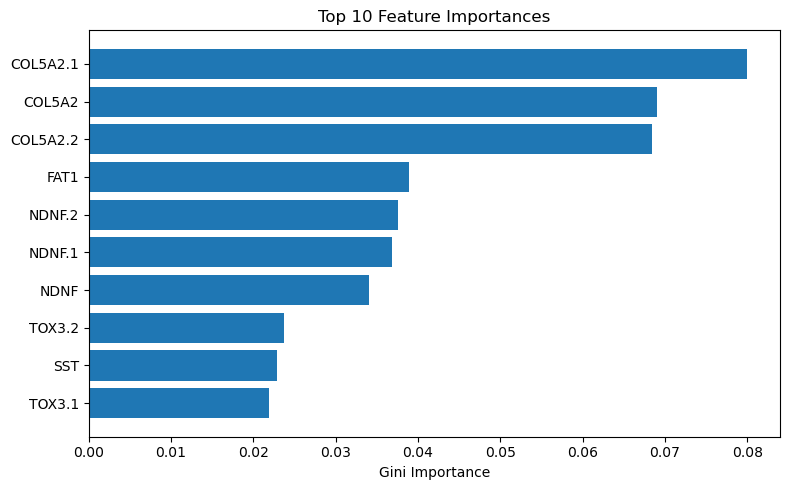

Figure saved to: ..\figures\top10_feature_importances.png


In [18]:
plot_top10 = feat_df.head(10)

plt.figure(figsize=(8, 5))
plt.barh(plot_top10["Feature"][::-1], plot_top10["Importance"][::-1])
plt.xlabel("Gini Importance")
plt.title("Top 10 Feature Importances")
plt.tight_layout()

figure_path = FIGURES_DIR / "top10_feature_importances.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:", figure_path)


## 12. Section 8: Final Runtime Test on Verification Database

The final Random Forest model is trained on the full training database and tested on the untouched verification database.


In [19]:
final_model = RandomForestClassifier(
    n_estimators=BEST_NTREE,
    max_features=BEST_MTRY,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

final_model.fit(X_train, y_train)

X_verification = verification_df.drop("Label", axis=1).values
y_verification = verification_df["Label"].values

y_pred_verification = final_model.predict(X_verification)
y_prob_verification = final_model.predict_proba(X_verification)

verification_results = pd.DataFrame({
    "Sample": range(1, len(y_verification) + 1),
    "True Label": y_verification,
    "Predicted Label": y_pred_verification,
    "Prob(Class 0)": y_prob_verification[:, 0].round(3),
    "Prob(Class 1)": y_prob_verification[:, 1].round(3),
})

verification_results


,Sample,True Label,Predicted Label,Prob(Class 0),Prob(Class 1)
0,1,1,1,0.088,0.912
1,2,0,0,0.840,0.160


## 13. Final Summary

This final cell prints the most important results from the full pipeline.


In [20]:
print("Best model settings:")
print(f"n_estimators = {BEST_NTREE}")
print(f"max_features = {BEST_MTRY}")
print()

print("OOB Accuracy:", round(oob_model.oob_score_, 5))
print("CV Accuracy:", round(cv_accuracy, 5))
print("Absolute Difference:", round(abs(oob_model.oob_score_ - cv_accuracy), 5))
print()

print("Top feature:", feat_df.iloc[0]["Feature"])
print("Verification predictions:", y_pred_verification.tolist())
print("True verification labels:", y_verification.tolist())


Best model settings:
n_estimators = 500
max_features = 50

OOB Accuracy: 0.98389
CV Accuracy: 0.98274
Absolute Difference: 0.00115

Top feature: COL5A2.1
Verification predictions: [1, 0]
True verification labels: [1, 0]
